## Retail Revenue and Cost Pattern Analysis Using SQL and Python

This project explores transactional retail data to identify hidden financial patterns, customer concentration effects, and revenue distribution signals using SQL-based aggregation inside Python.

Loading the Dataset

In [6]:
import pandas as pd
df = pd.read_excel("Online_Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Before running analysis, I first checked for missing values and dataset structure.

In [7]:
df.shape
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [21]:
df = df[df['UnitPrice'] > 0]

To simulate real-world business analysis workflows, I loaded the dataset into a SQLite database and used SQL queries to calculate revenue patterns across regions.

In [23]:
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('retail', conn, index=False, if_exists='replace')

530104

In [11]:
query = """
SELECT Country, SUM(Revenue) as TotalRevenue
FROM retail
GROUP BY Country
ORDER BY TotalRevenue DESC
"""

pd.read_sql(query, conn)

,Country,TotalRevenue
0,United Kingdom,9025222.084
1,Netherlands,285446.340
2,EIRE,283453.960
3,Germany,228867.140
4,France,209715.110
5,Australia,138521.310
6,Spain,61577.110
7,Switzerland,57089.900
8,Belgium,41196.340
9,Sweden,38378.330


Revenue is heavily concentrated in a small number of countries, with the United Kingdom contributing the largest share. This suggests potential geographic dependence and uneven revenue distribution.

## Revenue Distribution Patterns

I calculated transaction-level revenue to explore how income is distributed across customers, regions, and purchasing behaviors.

In [12]:
query = """
SELECT 
    Country,
    COUNT(*) as NumOrders,
    SUM(Quantity*UnitPrice) as TotalRevenue,
    AVG(Quantity*UnitPrice) as AvgOrderValue
FROM retail
GROUP BY Country
ORDER BY TotalRevenue DESC
"""
pd.read_sql(query, conn)

,Country,NumOrders,TotalRevenue,AvgOrderValue
0,United Kingdom,485123,9025222.084,18.603987
1,Netherlands,2359,285446.340,121.003111
2,EIRE,7890,283453.960,35.925724
3,Germany,9040,228867.140,25.317162
4,France,8407,209715.110,24.945297
5,Australia,1182,138521.310,117.192310
6,Spain,2484,61577.110,24.789497
7,Switzerland,1966,57089.900,29.038606
8,Belgium,2031,41196.340,20.283772
9,Sweden,451,38378.330,85.096075


This view highlights purchasing intensity differs and also where revenue is highest. Countries with fewer orders but high average order value may represent premium customer bases.

## Customer Revenue Concentration
Do small number of customers contribute a large share of total revenue?

In [13]:
query = """
SELECT 
    CustomerID,
    SUM(Quantity*UnitPrice) as CustomerRevenue
FROM retail
GROUP BY CustomerID
ORDER BY CustomerRevenue DESC
LIMIT 20
"""
pd.read_sql(query, conn)

,CustomerID,CustomerRevenue
0,NaN,1755276.64
1,14646.0,280206.02
2,18102.0,259657.30
3,17450.0,194550.79
4,16446.0,168472.50
5,14911.0,143825.06
6,12415.0,124914.53
7,14156.0,117379.63
8,17511.0,91062.38
9,16029.0,81024.84


## Identifying Revenue Risk Patterns

After understanding where revenue is generated geographically and across customers, next step is to identify hidden instability signals in transaction behavior.

## Hidden Cost Signals: Returns and Transaction Reversals

To understand this hidden layer, I examined where negative transactions were concentrated geographically.

In [14]:
returns_query = """
SELECT 
    Country,
    COUNT(*) as NumReturns,
    SUM(ABS(Quantity*UnitPrice)) as EstimatedReturnValue
FROM retail
WHERE Quantity < 0
GROUP BY Country
ORDER BY EstimatedReturnValue DESC
"""

pd.read_sql(returns_query, conn)

,Country,NumReturns,EstimatedReturnValue


## Customer Instability Patterns

I explored whether revenue was concentrated among a small number of customers and whether this creates dependency risk.

In [15]:
customer_orders = """
SELECT 
    CustomerID,
    COUNT(*) as NumTransactions,
    SUM(Quantity*UnitPrice) as TotalRevenue
FROM retail
WHERE CustomerID IS NOT NULL
GROUP BY CustomerID
ORDER BY TotalRevenue DESC
LIMIT 20
"""

pd.read_sql(customer_orders, conn)

,CustomerID,NumTransactions,TotalRevenue
0,14646.0,2076,280206.02
1,18102.0,431,259657.30
2,17450.0,337,194550.79
3,16446.0,3,168472.50
4,14911.0,5675,143825.06
5,12415.0,714,124914.53
6,14156.0,1400,117379.63
7,17511.0,963,91062.38
8,16029.0,242,81024.84
9,12346.0,1,77183.60


Interpretation: A small number of customers generate a particularly large share of total revenue. This creates dependency risk, where losing a handful of clients could significantly impact financial stability.

## Revenue Instability and Risk Signals

I examined signals that may indicate financial instability, including heavy dependence on specific regions, customers, and transaction reversals.


### Return-Driven Revenue Loss Signals

To identify hidden cost patterns, I examined negative quantity transactions, which represent product returns or order reversals. 


In [24]:
returns_ratio_query = """
SELECT 
    Country,
    SUM(CASE WHEN Quantity < 0 THEN ABS(Quantity*UnitPrice) ELSE 0 END) as ReturnValue,
    SUM(Quantity*UnitPrice) as TotalSales
FROM retail
GROUP BY Country
ORDER BY ReturnValue DESC
"""

pd.read_sql(returns_ratio_query, conn)

,Country,ReturnValue,TotalSales
0,Unspecified,0,4749.790
1,United Kingdom,0,9025222.084
2,United Arab Emirates,0,1902.280
3,USA,0,3580.390
4,Switzerland,0,57089.900
5,Sweden,0,38378.330
6,Spain,0,61577.110
7,Singapore,0,21279.290
8,Saudi Arabia,0,145.920
9,RSA,0,1002.310


In [27]:
df[df['Quantity'] < 0].shape

(0, 9)

## Transaction Intensity Patterns

In [28]:
query = """
SELECT
    CustomerID,
    COUNT(*) as NumTransactions,
    SUM(Quantity*UnitPrice) as TotalRevenue
FROM retail
WHERE CustomerID IS NOT NULL
GROUP BY CustomerID
ORDER BY NumTransactions DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,CustomerID,NumTransactions,TotalRevenue
0,17841.0,7847,40991.57
1,14911.0,5675,143825.06
2,14096.0,5111,65164.79
3,12748.0,4595,33719.73
4,14606.0,2700,12156.65
5,15311.0,2379,60767.90
6,14646.0,2076,280206.02
7,13089.0,1818,58825.83
8,13263.0,1677,7454.07
9,14298.0,1637,51527.30


This table shows that a small group of customers place a very high number of transactions compared to others. This suggests that revenue may be partially driven by a core group of highly active buyers rather than evenly distributed across all customers.

## Transaction Value Patterns

In [29]:
value_query = """
SELECT
    CustomerID,
    COUNT(*) as NumTransactions,
    AVG(Quantity*UnitPrice) as AvgOrderValue,
    SUM(Quantity*UnitPrice) as TotalRevenue
FROM retail
WHERE CustomerID IS NOT NULL
GROUP BY CustomerID
ORDER BY TotalRevenue DESC
LIMIT 10
"""
pd.read_sql(value_query, conn)

,CustomerID,NumTransactions,AvgOrderValue,TotalRevenue
0,14646.0,2076,134.973998,280206.02
1,18102.0,431,602.453132,259657.30
2,17450.0,337,577.302047,194550.79
3,16446.0,3,56157.500000,168472.50
4,14911.0,5675,25.343623,143825.06
5,12415.0,714,174.950322,124914.53
6,14156.0,1400,83.842593,117379.63
7,17511.0,963,94.561142,91062.38
8,16029.0,242,334.813388,81024.84
9,12346.0,1,77183.600000,77183.60


Interpretation: This view helps distinguish between customers who generate revenue through frequent low-value purchases and those who make fewer but higher-value transactions. It shows whether revenue is driven by loyalty, purchasing power, or both.

## Geographic Revenue Concentration (Visual)

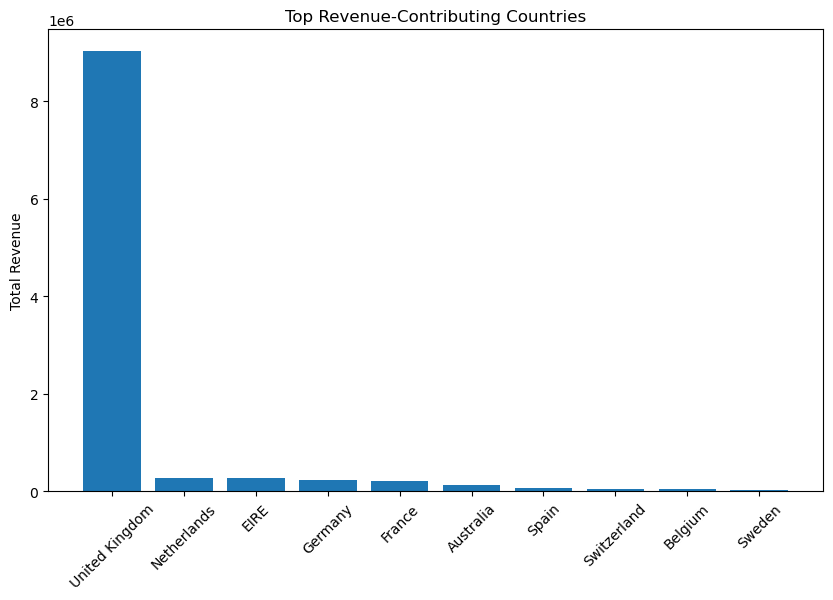

In [31]:
country_query = """
SELECT 
    Country,
    SUM(Quantity*UnitPrice) as TotalRevenue
FROM retail
GROUP BY Country
ORDER BY TotalRevenue DESC
"""

top_countries = pd.read_sql(country_query, conn).head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(top_countries['Country'], top_countries['TotalRevenue'])
plt.xticks(rotation=45)
plt.title("Top Revenue-Contributing Countries")
plt.ylabel("Total Revenue")
plt.show()

This visualization shows that revenue is highly concentrated in a small number of countries, with one or two regions contributing larger shares. This kind of concentration can create geographic dependency risk, where business performance becomes sensitive to regional changes.

## Customer Revenue Concentration (Visual)

To examine how revenue is distributed across individual customers, I visualized the highest revenue-generating clients. This helps determine whether the business depends heavily on a small group of buyers.

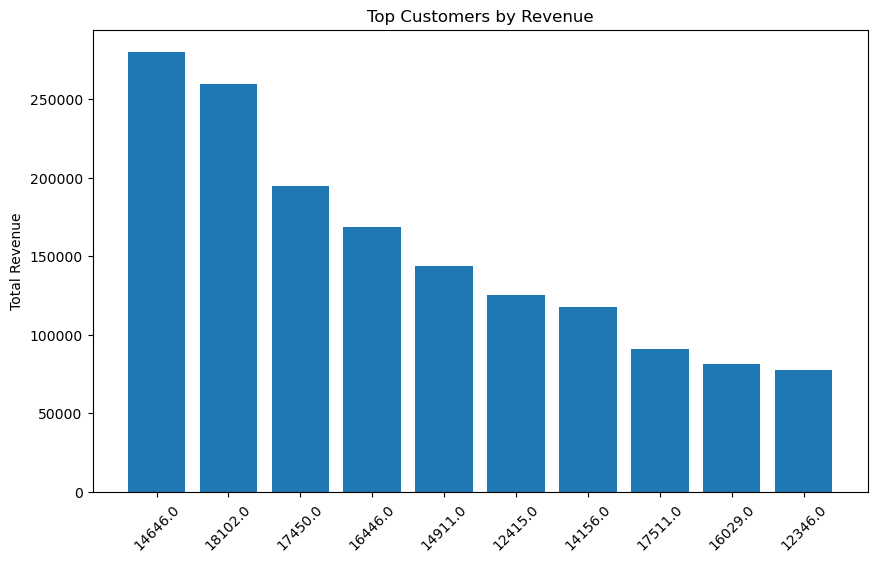

In [32]:
top_customers = pd.read_sql(value_query, conn)

plt.figure(figsize=(10,6))
plt.bar(top_customers['CustomerID'].astype(str), top_customers['TotalRevenue'])
plt.xticks(rotation=45)
plt.title("Top Customers by Revenue")
plt.ylabel("Total Revenue")
plt.show()

This chart highlights how a relatively small number of customers contribute a large portion of total revenue.

## Transaction Behavior Patterns

I explored whether revenue is driven by frequent low-value purchases or fewer high-value transactions by comparing order frequency and average order value across top customers.

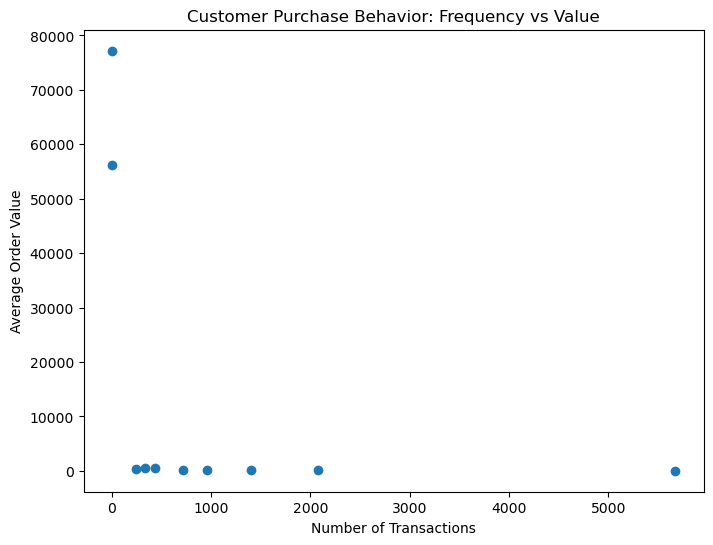

In [33]:
plt.figure(figsize=(8,6))
plt.scatter(top_customers['NumTransactions'], top_customers['AvgOrderValue'])

plt.xlabel("Number of Transactions")
plt.ylabel("Average Order Value")
plt.title("Customer Purchase Behavior: Frequency vs Value")
plt.show()

This view separates high-frequency buyers from high-value buyers. Some customers generate revenue through repeated small purchases, while others contribute through occasional but high-value transactions.

## Revenue Inequality

To understand how uneven revenue distribution is, I compared the total revenue generated by the top customers versus the rest.

In [34]:
total_revenue = df['Quantity'] * df['UnitPrice']
print("Approx total revenue:", total_revenue.sum())

Approx total revenue: 10666684.544


This suggests that a small segment of customers drives a substantial share of total revenue, reinforcing patterns of concentration observed earlier.

## Revenue Trend Over Time

To understand whether revenue patterns change over time, I examined monthly revenue trends. This will help identify seasonality, growth phases, and potential instability periods.

C:\Users\priyanka\AppData\Local\Temp\ipykernel_26896\3137861440.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_revenue = df.groupby('Month').apply(


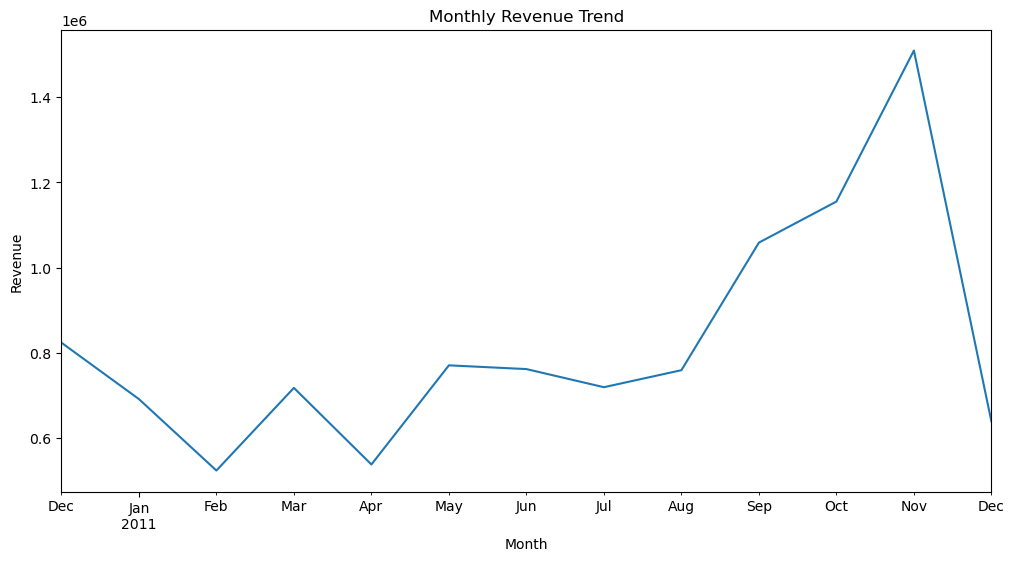

In [35]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = df.groupby('Month').apply(
    lambda x: (x['Quantity'] * x['UnitPrice']).sum()
)

monthly_revenue.plot(figsize=(12,6))
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xlabel("Month")
plt.show()

This time-based view reveals how revenue evolves across months. Periods of spikes may indicate seasonal demand, while drops may signal instability. 

## Geographic Dependency Risk

I calculated what percentage of total revenue comes from each country to understand how dependent the business is on specific regions.

In [36]:
country_rev = df.groupby('Country').apply(
    lambda x: (x['Quantity'] * x['UnitPrice']).sum()
)

country_share = (country_rev / country_rev.sum()) * 100
country_share.sort_values(ascending=False).head(10)

C:\Users\priyanka\AppData\Local\Temp\ipykernel_26896\928062417.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  country_rev = df.groupby('Country').apply(


Country
United Kingdom    84.611315
Netherlands        2.676055
EIRE               2.657376
Germany            2.145626
France             1.966076
Australia          1.298635
Spain              0.577284
Switzerland        0.535217
Belgium            0.386215
Sweden             0.359796
dtype: float64

Heavy reliance on one country increases exposure to local economic shifts, regulations, or demand fluctuations.

Across this analysis, patterns of concentration emerged at multiple levels including country, customer, and purchasing behavior. These signals suggest that revenue stability may depend on a relatively narrow base, making the system sensitive to disruptions.

## Takeaways
Several patterns stood out to me through this analysis. Revenue is heavily concentrated in a small number of countries, which suggests geographic dependency. A relatively small group of customers contributes a significantly large share of total income, indicating potential concentration risk if those customers were lost. Transaction-level patterns also show that some customers generate revenue through frequent smaller purchases, while others contribute through fewer but high-value transactions. The time-based analysis further revealed seasonal variation in purchasing behavior, with revenue rising and falling across months. This suggests that business performance may be influenced by cyclical demand patterns rather than steady activity. Taken together, these findings show how revenue systems often depend on a limited set of drivers like specific markets, high-value customers, and seasonal trends. Viewing data through this systems-level lens helps identify where organizations may be financially stable versus structurally vulnerable.